<a href="https://colab.research.google.com/github/clleone/ds-20195-final/blob/main/clleone_ds_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [211]:
!pip install -q geopandas
!pip install -q census
!pip install -q us
!pip install -q pygris

In [212]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from census import Census
from us import states
import pygris
from shapely.geometry import Point
from shapely.strtree import STRtree

# Analyzing US Maternal Mortality - Introduction #

A maternal death is defined by the World Health Organization as “the death of a woman while pregnant or within 42 days of termination of pregnancy, irrespective of the duration and the site of the pregnancy, from any cause related to or aggravated by the pregnancy or its management, but not from accidental or incidental causes”. (Consequently, suicides are excluded from these statistics.)

CDC Wonder's Underlying Cause of Mortality dataset is a resource that keeps track of these events through death certificates. Cause of death are recorded on death certificates by physicians based on ICD 10 codes. Relevant ICD 10 codes that are traditionally referenced in the construction of maternal mortality statistics include:
- A34 (Obstetric Tetanus)
- O01-95
- O98-99

To protect identities, CDC Wonder will mark any statistic with at least one but fewer than 10 incidents as "Suppressed". Given that maternal mortality is a relatively uncommon event, with about ~700 occurring in the US annually, this restriction makes it difficult to do granular analysis with public data resoures. Nevertheless, what we can see still reveals some important insights.

To start with, we can look at an aggregation of data from 2018-2024. ICD 10 reporting standards surrounding pregnancy were inconsistent from state to state preceding 2018, hence this unit of time. [[1]](https://wonder.cdc.gov/wonder/help/ucd-expanded.html#)[[2]](https://www.cdc.gov/nchs/data/hestat/maternal-mortality/2023/maternal-mortality-rates-2023.htm)

In [213]:
# CDC Wonder Underlying Cause of Death statistics 2018-2024 cumulative

# by state, cutting out disclaimer at bottom
matmort_by_state = pd.read_csv("https://raw.githubusercontent.com/clleone/ds-20195-final/refs/heads/main/data/maternal_mort_data/maternal-mort-by-state.csv")[:52]

# by county
# matmort_by_age.loc[matmort_by_age['Notes'] == '---']
matmort_by_county = pd.read_csv("https://raw.githubusercontent.com/clleone/ds-20195-final/refs/heads/main/data/maternal_mort_data/maternal-mort-by-county.csv")[:1475]
matmort_by_county['County Code'] = matmort_by_county['County Code'].astype('int').astype('string').str.zfill(5)

In addition to regions/statistics with fewer than 10 observations being suppressed, additional regions with 10 or more observations may also be suppressed if necessary to prevent back-calculation. Geospatially, we see data suppression starting at the state level. Looking between the different datasets, we can see that at the state level there are 10 deaths total between suppressed states Delaware and Vermont.

In [214]:
# two states reported <10 maternal mortalities 2018-2024

matmort_by_state[matmort_by_state['Deaths'] == 'Suppressed']

,Notes,State,State Code,Deaths,Population,Crude Rate,Crude Rate Lower 95% Confidence Interval,Crude Rate Upper 95% Confidence Interval
7,NaN,Delaware,10.0,Suppressed,3420621.0,Suppressed,Suppressed,Suppressed
45,NaN,Vermont,50.0,Suppressed,2215371.0,Suppressed,Suppressed,Suppressed


In [215]:
# suppressed county analysis, assuming 3144 non-territory counties or equivalents (including DC)

suppressed_counties = len(matmort_by_county[matmort_by_county['Deaths'] == "Suppressed"])/3144 * 100
non_suppressed_counties = (len(matmort_by_county[matmort_by_county['Deaths'] != "Suppressed"]))/3144 * 100

print(f"{suppressed_counties:.2f}% of counties reported at least one but <10 maternal mortalities in 2018-2024.")
print(f"{non_suppressed_counties:.2f}% of counties reported 10 or more maternal mortalities in 2018-2024.")


42.91% of counties reported at least one but <10 maternal mortalities in 2018-2024.
4.01% of counties reported 10 or more maternal mortalities in 2018-2024.


In [216]:
# attach geometries to county-level data
matmort_by_county['GEOID'] = matmort_by_county['County Code']
us_counties = gpd.read_file("https://github.com/clleone/ds-20195-final/raw/refs/heads/main/data/tl_2025_us_county.zip")
counties_w_matmort_gdf = us_counties.merge(matmort_by_county, how='left', on='GEOID')

Let's take a look at where affected counties are located.

In [217]:
# change "Suppressed" to 1s and cast everything else to integers
def convert_suppressed_to_ones(deaths):
  if deaths == 'Suppressed':
    return 1
  elif type(deaths) == str:
    return int(deaths)
  else:
    return 0

# create dummy variable for counties that observed any maternal mortalities
def has_matmort(deaths):
  if deaths == 0:
    return 0
  else:
    return 1

counties_w_matmort_gdf['Deaths'] = counties_w_matmort_gdf['Deaths'].apply(convert_suppressed_to_ones)
counties_w_matmort_gdf['has_matmort'] = counties_w_matmort_gdf['Deaths'].apply(has_matmort)

In [218]:
# dropping Puerto Rico and territories
counties_w_matmort_gdf = counties_w_matmort_gdf[counties_w_matmort_gdf['STATEFP'].astype(int) <= 56]

/tmp/ipykernel_29078/955403328.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


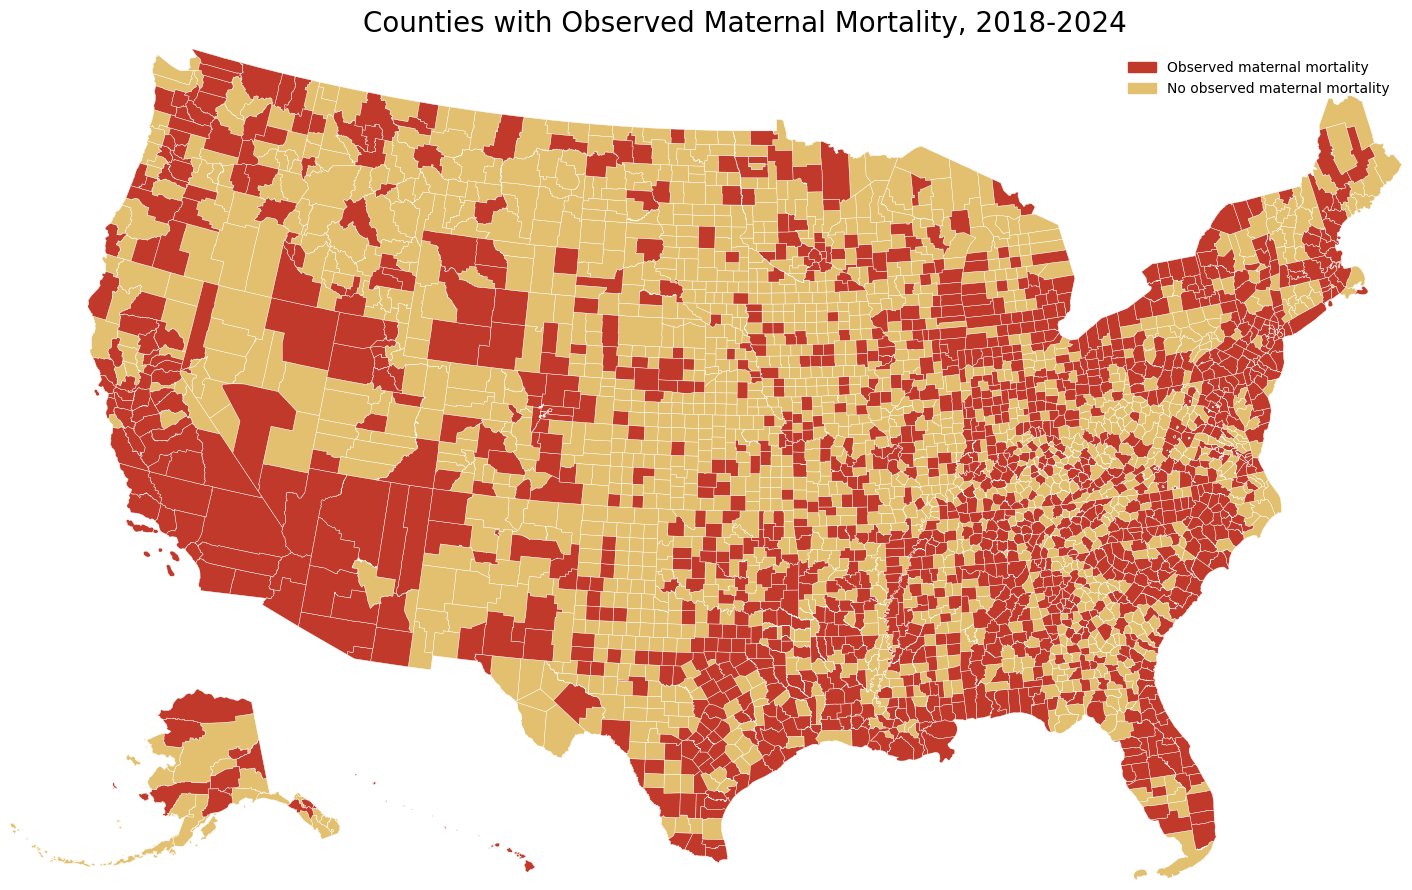

In [219]:
# plot counties that reported any maternal mortalities in 2018-2024
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# split into three geodataframes
lower48 = counties_w_matmort_gdf[~counties_w_matmort_gdf["STATEFP"].isin(["02", "15"])]
alaska  = counties_w_matmort_gdf[counties_w_matmort_gdf["STATEFP"] == "02"]
hawaii  = counties_w_matmort_gdf[counties_w_matmort_gdf["STATEFP"] == "15"]

lower48 = lower48.to_crs("EPSG:5070")
alaska  = alaska.to_crs("EPSG:3338")
hawaii  = hawaii.to_crs("EPSG:6628")

def plot_counties(ax, gdf_subset):
    gdf_subset[gdf_subset["has_matmort"] == 0].plot(
        ax=ax, color="#e3c06f", edgecolor="white", linewidth=0.3)
    gdf_subset[gdf_subset["has_matmort"] == 1].plot(
        ax=ax, color="#c0392b", edgecolor="white", linewidth=0.3)
    ax.axis("off")

fig, ax = plt.subplots(figsize=(15, 9))

# lower 48
plot_counties(ax, lower48)
minx, miny, maxx, maxy = lower48.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)
ax.axis("off")

# Alaska
ax_alaska = fig.add_axes([0.01, 0.02, 0.22, 0.22])
plot_counties(ax_alaska, alaska)
ax_alaska.set_xlim(alaska.total_bounds[[0, 2]])
ax_alaska.set_ylim(alaska.total_bounds[[1, 3]])

# Hawaii
ax_hawaii = fig.add_axes([0.24, 0.02, 0.12, 0.12])
plot_counties(ax_hawaii, hawaii)
ax_hawaii.set_xlim(hawaii.total_bounds[[0, 2]])
ax_hawaii.set_ylim(hawaii.total_bounds[[1, 3]])

legend_handles = [
    mpatches.Patch(color="#c0392b", label="Observed maternal mortality"),
    mpatches.Patch(color="#e3c06f", label="No observed maternal mortality"),
]
ax.legend(handles=legend_handles, loc="upper right", frameon=False, fontsize=10)

ax.set_title("Counties with Observed Maternal Mortality, 2018-2024", fontsize=20, pad=12)
ax.axis("off")

plt.tight_layout()
plt.show()


We see a wide spread of affected counties throughout the country. To better understand in what context these events are occurring, let's look at urbanicity. While the US Census assigns a binary "urban/rural" classifier to counties, the National Center for Health Statistics has its own 6-tier classification system for counties ranging from most urban to most rural. [[3]](https://www.cdc.gov/nchs/data-analysis-tools/urban-rural.html)

In [220]:
# urbanization analysis of counties represented
nchs_classifications = pd.read_csv('https://raw.githubusercontent.com/clleone/ds-20195-final/refs/heads/main/data/NCHS-Urban-Rural-Classification.csv')
nchs_classifications['Location'] = nchs_classifications['Location'].astype(str).str.zfill(5)
nchs_classifications['GEOID'] = nchs_classifications['Location']

In [221]:
counties_w_nhcs = nchs_classifications[['GEOID', '2023 Code']].merge(matmort_by_county, how='left', on='GEOID')
counties_w_nhcs['Deaths'] = counties_w_nhcs['Deaths'].apply(convert_suppressed_to_ones)
counties_w_nhcs['has_matmort'] = counties_w_nhcs['Deaths'].apply(has_matmort)

In [222]:
counts = counties_w_nhcs.groupby(["2023 Code", "has_matmort"]).size().unstack(fill_value=0)
pct = counts.div(counts.sum(axis=1), axis=0) * 100

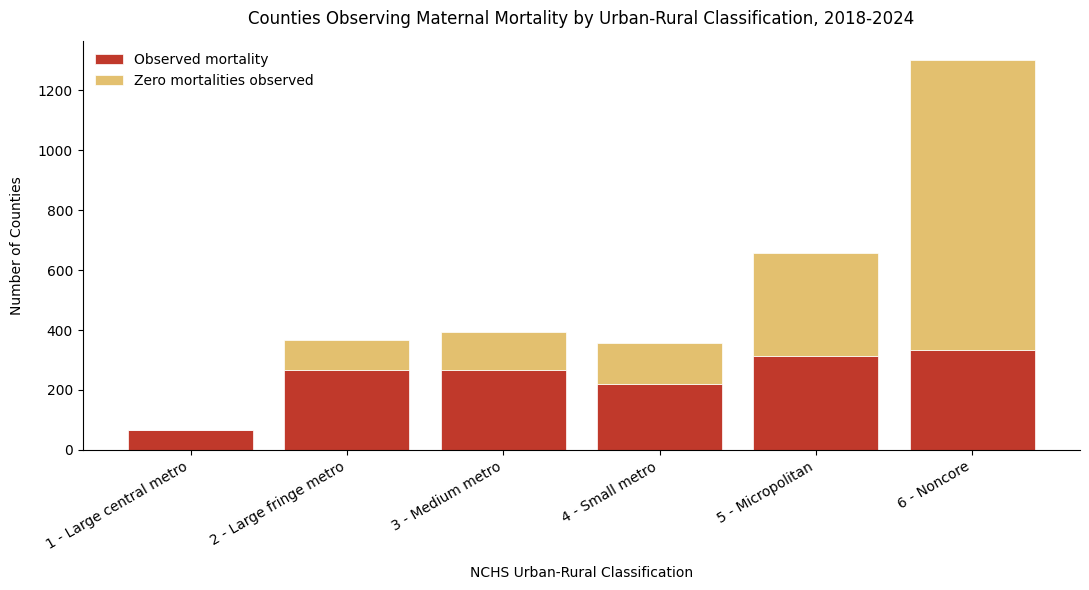

In [223]:
# counties sorted by NCHS 2023 Urban-Rural Classification scheme
fig, ax = plt.subplots(figsize=(11, 6))

ax.bar(counts.index, counts[1], color="#c0392b", label="Observed mortality", edgecolor="white", linewidth=0.5)
ax.bar(counts.index, counts[0], bottom=counts[1], color="#e3c06f", label="Zero mortalities observed", edgecolor="white", linewidth=0.5)

ax.set_ylabel("Number of Counties", labelpad=10)
ax.set_xlabel("NCHS Urban-Rural Classification", labelpad=10)
ax.set_title("Counties Observing Maternal Mortality by Urban-Rural Classification, 2018-2024", pad=12)

ax.set_xticks(range(len(counts.index)))
ax.set_xticklabels(counts.index, rotation=30, ha="right")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(loc="upper left", frameon=False)

plt.tight_layout()
plt.show()

If we were to conservatively band our estimate and say that all suppressed counties only observed a single maternal mortality between 2018-2024, we would observe the following percentages of events by urbanicity.

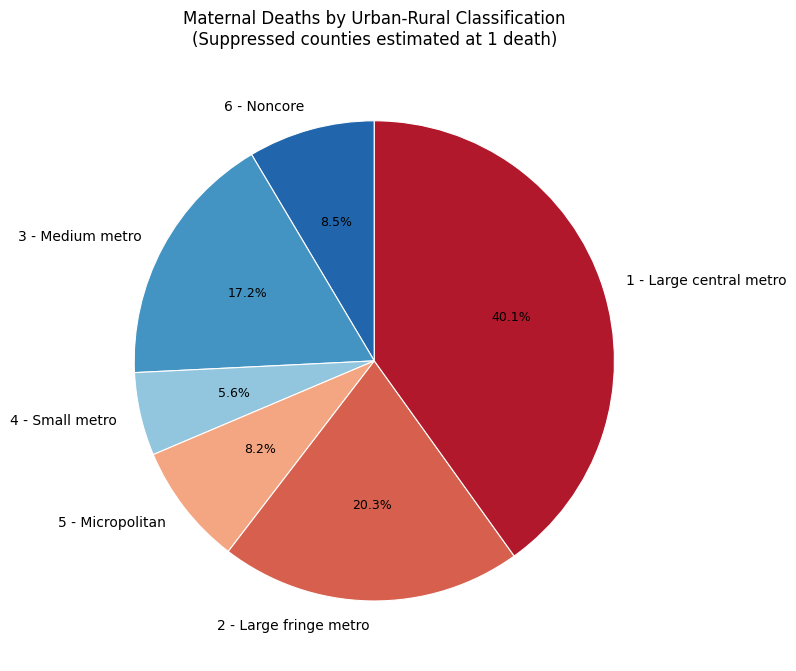

In [224]:
# pie chart representation
category_order = [cat for cat in counties_w_nhcs["2023 Code"].unique()]
urban_deaths = counties_w_nhcs.groupby("2023 Code")["Deaths"].sum().reindex(category_order)

fig, ax = plt.subplots(figsize=(8, 8))

wedges, texts, autotexts = ax.pie(
    urban_deaths.values,
    labels=urban_deaths.index,
    autopct="%1.1f%%",
    colors=["#2166ac", "#4393c3", "#92c5de", "#f4a582", "#d6604d", "#b2182b"],
    startangle=90,
    wedgeprops=dict(edgecolor="white", linewidth=0.8)
)

for text in texts:
    text.set_fontsize(10)
for autotext in autotexts:
    autotext.set_fontsize(9)

ax.set_title("Maternal Deaths by Urban-Rural Classification\n(Suppressed counties estimated at 1 death)",
             pad=12, fontsize=12)

plt.tight_layout()
plt.show()

As the pie chart suggests, when we look at counties with the highest maternal mortality rates, we see several of the most populous counties in the US.

In [225]:
# top 15 counties by total maternal mortalities in 2018-2024
counties_w_matmort_gdf[counties_w_matmort_gdf['Deaths'] >= 10 ][['County', 'Deaths']].sort_values('Deaths', ascending=False)[:16]

,County,Deaths
1574,"Harris County, TX",120
1918,"Maricopa County, AZ",90
1138,"Cook County, IL",76
2298,"Dallas County, TX",74
1993,"Los Angeles County, CA",70
1357,"Bexar County, TX",57
2271,"Shelby County, TN",47
1530,"Tarrant County, TX",45
2455,"Kings County, NY",44
939,"Miami-Dade County, FL",37


Before assuming maternal mortality is a predominantly urban problem, we must normalize our data. Instead of normalizing by general population, as is convention for many other standard statistics, maternal mortality rates are typically calculated as the number of maternal deaths per 100,000 live births. [[2]](https://www.google.com/url?q=https%3A%2F%2Fwww.cdc.gov%2Fnchs%2Fdata%2Fhestat%2Fmaternal-mortality%2F2023%2Fmaternal-mortality-rates-2023.htm)

The CDC Wonder datasets also contain natality statistics. Similarly to the previous dataset, statistics with observations of fewer than 10 are suppressed, but more tricky yet for the purposes of normalizing our statistics, counties with fewer than 100,000 residents are excluded. You can see this in a heatmap of missingness below. To keep exploring urbanicity, let's focus on the subset of nonsuppressed counties, which lean urban. [[4]](https://wonder.cdc.gov/wonder/help/natality-expanded.html#)




In [226]:
# CDC Wonder Natality statistics 2018-2024 cumulative

# by state, cutting out disclaimer at bottom
natal_by_state = pd.read_csv("https://raw.githubusercontent.com/clleone/ds-20195-final/refs/heads/main/data/natality_data/natal_by_state.csv")

# by county
natal_by_county = pd.read_csv("https://raw.githubusercontent.com/clleone/ds-20195-final/refs/heads/main/data/natality_data/natal-by-state-county.csv")

In [227]:
# join natality data onto maternal mortality gdf
natal_by_county['County of Residence Code'] = natal_by_county['County of Residence Code'].astype('string').str[:-2].str.zfill(5)
natal_by_county['GEOID'] = natal_by_county['County of Residence Code']
counties_w_matmort_gdf = counties_w_matmort_gdf.merge(natal_by_county[['GEOID', 'Births', 'State of Residence']], how="left", on="GEOID")

In [228]:
def classify_deaths(row):
    if row["Deaths"] >= 10:
        return ">=10 Deaths\nReported"
    elif row["Deaths"] == 1:
        return "1–9 Deaths\n(Suppressed)"
    else:
        return "No Deaths\nReported"

def classify_births(row):
    if row['Births'] > 0:
        return ">=100k population"
    else:
        return "<100k population"

counties_w_matmort_gdf["death_status"] = counties_w_matmort_gdf.apply(classify_deaths, axis=1)
counties_w_matmort_gdf["pop_category"] = counties_w_matmort_gdf.apply(classify_births, axis=1)

death_order = [">=10 Deaths\nReported", "1–9 Deaths\n(Suppressed)", "No Deaths\nReported"]
pop_order   = [">=100k population", "<100k population"]
table = counties_w_matmort_gdf.groupby(["pop_category", "death_status"]).size().unstack(fill_value=0)
table = table.reindex(index=pop_order, columns=death_order)
table = table.fillna(0).values


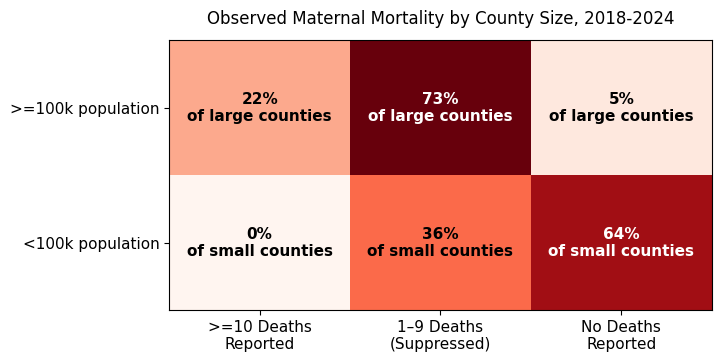

In [268]:
# missing data crosstab table
values = table / table.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(7, 3.5))

im = ax.imshow(values, cmap="Reds", aspect="auto")

ax.set_xticks(range(len(death_order)))
ax.set_xticklabels(death_order, fontsize=11)
ax.set_yticks(range(len(pop_order)))
ax.set_yticklabels(pop_order, fontsize=11)
ax.set_title("Observed Maternal Mortality by County Size, 2018-2024", pad=12)

for i in range(len(pop_order)):
    for j in range(len(death_order)):
        text_color = "white" if im.norm(values[i, j]) > 0.6 else "black"
        if i == 0:
            ax.text(j, i, f"{values[i, j]:.0f}%\nof large counties",
                ha="center", va="center",
                fontsize=11, color=text_color, fontweight="bold")
        else:
            ax.text(j, i, f"{values[i, j]:.0f}%\nof small counties",
                ha="center", va="center",
                fontsize=11, color=text_color, fontweight="bold")

In [231]:
# looking at non-suppressed counties, counties with at least 10 observations
counties_gt_10 = counties_w_matmort_gdf[counties_w_matmort_gdf['Deaths'] >= 10][['GEOID','County', 'State of Residence', 'Deaths', 'Births']].sort_values('Deaths', ascending=False)
counties_gt_10['matmort_rate'] = round((counties_gt_10['Deaths'] / counties_gt_10['Births'] * 100000), 2)
counties_gt_10 = counties_gt_10.merge(nchs_classifications[['GEOID', '2023 Code']], how='left', on='GEOID')
counties_gt_10['2023 Code'].unique()

array(['1 - Large central metro', '2 - Large fringe metro',
       '3 - Medium metro', '5 - Micropolitan'], dtype=object)

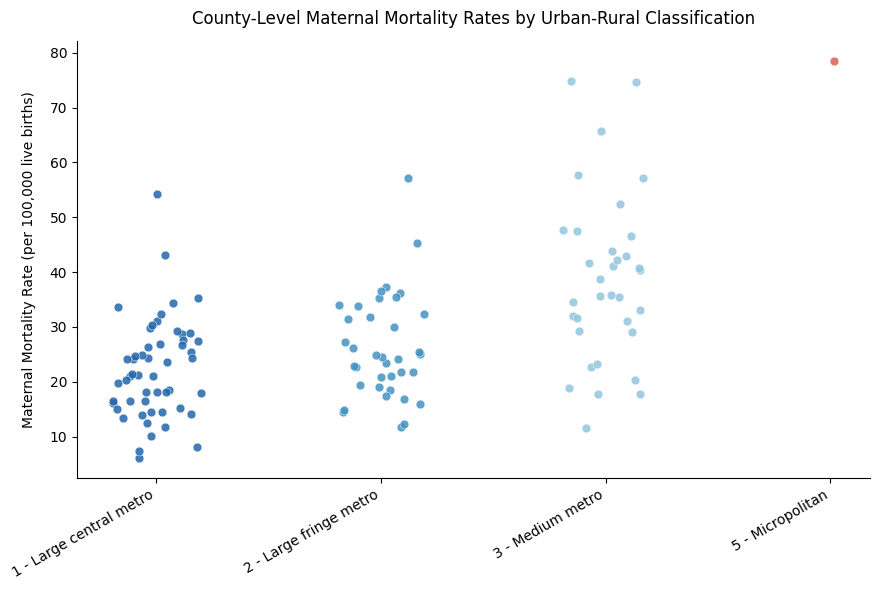

In [232]:
# jitter chart of counties' maternal mortality rates for counties >=10
import numpy as np
category_order = [cat for cat in counties_gt_10['2023 Code'].unique()]

colors = ["#2166ac","#4393c3","#92c5de","#d6604d"]

c_dict = dict(zip(category_order, colors))

fig, ax = plt.subplots(figsize=(9, 6))

for i, category in enumerate(category_order):
    subset = counties_gt_10[counties_gt_10["2023 Code"] == category]["matmort_rate"]
    x = np.random.uniform(i - 0.2, i + 0.2, size=len(subset))
    ax.scatter(x, subset, color=c_dict[category], alpha=0.85, s=40, edgecolor="white", linewidth=0.4)

ax.set_xticks(range(len(category_order)))
ax.set_xticklabels(category_order, rotation=30, ha="right")
ax.set_ylabel("Maternal Mortality Rate (per 100,000 live births)", labelpad=10)
ax.set_title("County-Level Maternal Mortality Rates by Urban-Rural Classification", pad=12)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

Although it's hard to draw any definitive conclusions with such small and restricted sample sizes, looking at the first three urban cateogires, our plot suggests a tentative trend of worse maternal mortality rates as counties become more rural.

Most notably in the plot, the outlier Micropolitan county we see in red is Robeson County, in North Carolina, with a maternal mortality rate of roughly 78.59 (per 100k live births) during 2018-2024. Predominantly agricultural, racially diverse, and consistently low-ranking in socioeconomic indicators compared to other counties in North Carolina, Robeson captures the intersection of several high-risk profiles for maternal mortality. [[5]](https://www.commonwealthfund.org/publications/issue-briefs/2024/jun/insights-us-maternal-mortality-crisis-international-comparison?utm_adgroup=&device=c&creative=&matchtype=&placement=&adposition=&network=x&utm_source=google&utm_medium=cpc&utm_campaign=&utm_term=&hsa_acc=1924159231&hsa_cam=22354259180&hsa_grp=&hsa_ad=&hsa_src=x&hsa_tgt=&hsa_kw=&hsa_mt=&hsa_net=adwords&hsa_ver=3&gad_source=1&gad_campaignid=22357980901&gbraid=0AAAAAD-XyuNGpuQWdr8lmqLWwfkbc3jgE&gclid=Cj0KCQjwz9_QBhD_ARIsADnSCfA_Upgg1ywFh2nM5DvPfFJTBIJIPESAGGg9lY742SvnWjDD5LD7498aAt33EALw_wcB)[[6]](https://en.wikipedia.org/wiki/Robeson_County,_North_Carolina)

## US Maternal Healthcare Access ##

To better understand what informs this trend, I wanted to look at maternal healthcare access, specifically accredited birthing facilities. The Centers for Medicare & Medicaid Services (CMS)'s Birthing-Friendly Hospitals and Health Systems dataset contains point data for hospitals and health facilities that:
- "Participated in a statewide or national perinatal quality improvement collaborative program; and,"
- "Implemented evidence-based quality interventions in hospital settings to improve maternal health."
[[7]](https://data.cms.gov/provider-data/birthing-friendly-hospitals-and-health-systems)


Although there may be populations that, during an otherwise safe birth, are better served in alternative settings, having swift access to certain kinds of interventions that can only take place in a hospital are critical in the event of an emergency. [[8]](https://www.ncbi.nlm.nih.gov/sites/books/NBK555483/) [[9]](https://www.ncbi.nlm.nih.gov/sites/books/NBK555483/)


Inspired by discussion in class of [Friedler/Lum's](https://sorelle.friedler.net/papers/polling_access_facct.pdf) distance ratio where they looked at election site distances normalized by distances to the nearest school or library, I computed 'as-the-crow-flies' distance ratios with hospitals compared to schools. I figured schools would be an appropriate choice, as parents and parents-to-be specifically seek proximity to them.


In order to do this, I gathered Census tract centroids with the population of reproductive-age women attached, computed the distance to the nearest hospital and school, and then divided the hospital distance by school distance. To create the choropleth, I calculated the average log ratio weighted by female-reproductive-age-population at the county level.

In [233]:
# load in birthing-hospitals and schools
df = pd.read_csv("https://raw.githubusercontent.com/clleone/ds-20195-final/refs/heads/main/data/Birthing_Friendly_Hospitals_Geocoded.csv")

birthing_hospitals = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df['lon'], df['lat']),
    crs="EPSG:5070" # good for calculating distances
)

schools_gdf = gpd.read_file(
    "https://raw.githubusercontent.com/clleone/ds-20195-final/refs/heads/main/data/Public_School_Locations_2022-23_.geojson"
    ).to_crs("EPSG:5070")

schools_gdf = schools_gdf[['OBJECTID', 'NCESSCH', 'NAME', 'OPSTFIPS', 'STATE', 'geometry']]

In [266]:
# pulling in tract census data for reproductive-age women
# c = Census(api_key_goes_here)

# variables = [
#     "NAME",         # Age cohorts
#     "B01001_027E",  # 15-17 (exclude)
#     "B01001_028E",  # 18-19
#     "B01001_029E",  # 20
#     "B01001_030E",  # 21
#     "B01001_031E",  # 22-24
#     "B01001_032E",  # 25-29
#     "B01001_033E",  # 30-34
#     "B01001_034E",  # 35-39
#     "B01001_035E",  # 40-44
#     "B01001_036E",  # 45-49
# ]

# all_pop_data = []
# for state in states.STATES:
#     result = c.acs5.state_county_tract(variables, state_fips=state.fips,
#                                         county_fips="*", tract="*", year=2022)
#     all_pop_data.extend(result)

# repro_pops = pd.DataFrame(all_pop_data)

In [265]:
# backup for census info
repro_pops = pd.read_csv("https://raw.githubusercontent.com/clleone/ds-20195-final/refs/heads/main/data/2022_repro_pop_women_by_tract.csv")

In [ ]:
# add up reproductive-age-women populations
cols = [col for col in repro_pops.columns if col.startswith("B01001_")]
repro_pops[cols] = repro_pops[cols].apply(pd.to_numeric, errors="coerce")

female_age_cols = [f"B01001_{str(i).zfill(3)}E" for i in range(27, 37)]
repro_pops["repro_age_women"] = repro_pops[female_age_cols].sum(axis=1)

repro_pops["GEOID"] = repro_pops["state"] + repro_pops["county"] + repro_pops["tract"]

In [240]:
# retrieve census tract geometries
all_tracts = []

for state in states.STATES:
    tracts_state = pygris.tracts(state=state.fips, year=2022, cb=True)
    all_tracts.append(tracts_state)

tracts = pd.concat(all_tracts, ignore_index=True)

# merge on pop data and extract centroids
tracts = tracts.merge(repro_pops[["GEOID", "repro_age_women"]], on="GEOID", how="left")
repro_pop_tracts = tracts.to_crs("EPSG:5070")
repro_pop_tracts['geometry'] = repro_pop_tracts.geometry.centroid

In [243]:
# shapely's STRtree speeds up distance calculations

hospital_tree = STRtree(birthing_hospitals.geometry.values)
school_tree   = STRtree(schools_gdf.geometry.values)

repro_pop_tracts["nearest_hospital_dist"] = repro_pop_tracts.geometry.apply(
    lambda pt: pt.distance(birthing_hospitals.geometry.iloc[hospital_tree.nearest(pt)])
)

repro_pop_tracts["nearest_school_dist"] = repro_pop_tracts.geometry.apply(
    lambda pt: pt.distance(schools_gdf.geometry.iloc[school_tree.nearest(pt)])
)

repro_pop_tracts["hospital_school_ratio"] = (
    repro_pop_tracts["nearest_hospital_dist"] /
    repro_pop_tracts["nearest_school_dist"].replace(0, float("nan"))
)

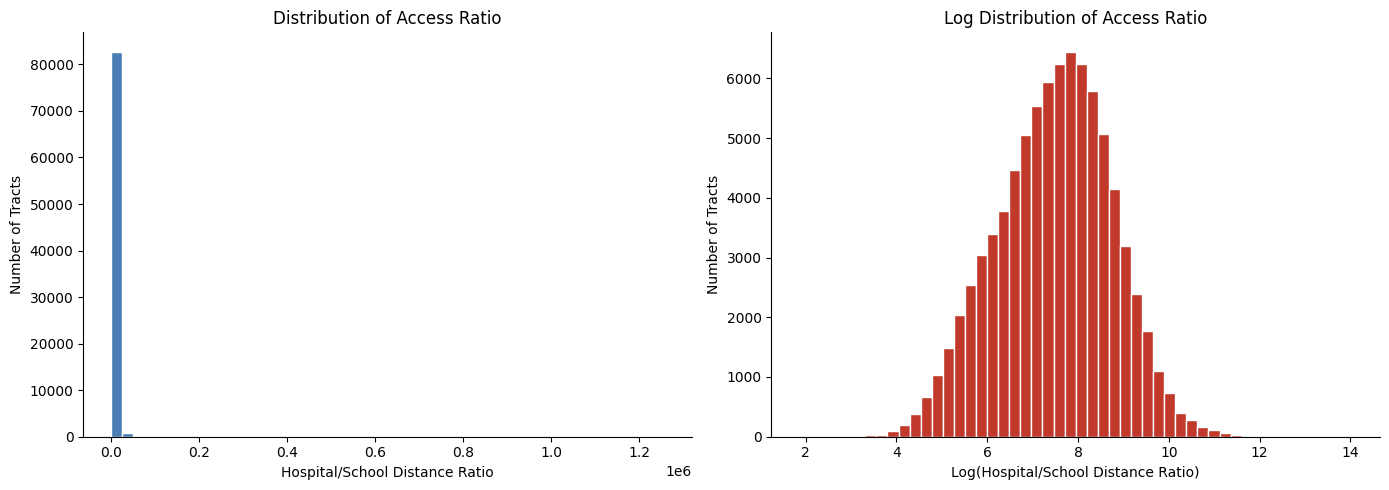

In [244]:
# quick look at ratio distributions, BIG right skew!
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# raw distribution
axes[0].hist(repro_pop_tracts["hospital_school_ratio"].dropna(), bins=50, color="#4a7fb5", edgecolor="white")
axes[0].set_xlabel("Hospital/School Distance Ratio")
axes[0].set_ylabel("Number of Tracts")
axes[0].set_title("Distribution of Access Ratio")
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# log distribution
axes[1].hist(np.log1p(repro_pop_tracts["hospital_school_ratio"].dropna()), bins=50, color="#c0392b", edgecolor="white")
axes[1].set_xlabel("Log(Hospital/School Distance Ratio)")
axes[1].set_ylabel("Number of Tracts")
axes[1].set_title("Log Distribution of Access Ratio")
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [248]:
# log ratio
repro_pop_tracts["log_ratio"] = np.log1p(repro_pop_tracts["hospital_school_ratio"])

In [250]:
# bring weighted average log ratio up to county level
def weighted_mean(group, value_col, weight_col):
    weights = group[weight_col].fillna(0)
    values  = group[value_col]
    mask    = weights > 0 & values.notna()
    if mask.sum() == 0:
        return np.nan
    return np.average(values[mask], weights=weights[mask])

county_ratio = (repro_pop_tracts.groupby("COUNTYFP")
                .apply(weighted_mean,
                       value_col="log_ratio",
                       weight_col="repro_age_women")
                .reset_index()
                .rename(columns={0: "weighted_log_ratio"}))

/tmp/ipykernel_29078/2783989420.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(weighted_mean,


In [259]:
# attach county geometries and restrict to 50 states
county_ratio_gdf = us_counties.merge(county_ratio, how='right', on='COUNTYFP')
county_ratio_gdf = county_ratio_gdf[county_ratio_gdf['STATEFP'].astype(int) <= 56]

/tmp/ipykernel_29078/3735225254.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


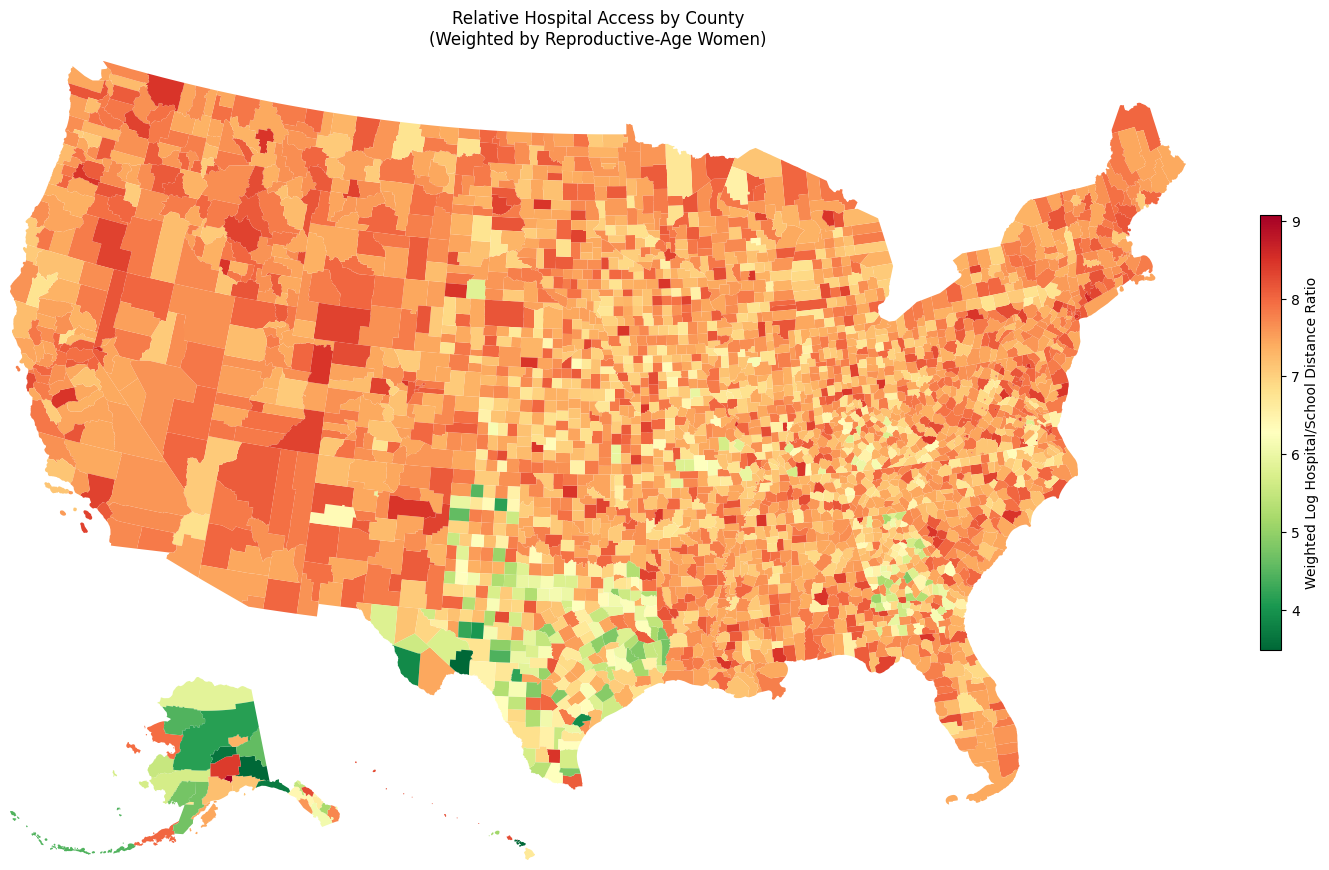

In [264]:
fig, ax = plt.subplots(figsize=(15, 9))

# split again
lower48 = county_ratio_gdf[~county_ratio_gdf["STATEFP"].isin(["02", "15"])].to_crs("EPSG:5070")
alaska  = county_ratio_gdf[county_ratio_gdf["STATEFP"] == "02"].to_crs("EPSG:3338")
hawaii  = county_ratio_gdf[county_ratio_gdf["STATEFP"] == "15"].to_crs("EPSG:6628")

plot_kwargs = dict(
    column="weighted_log_ratio",
    cmap="RdYlGn_r",
    legend=False,
    missing_kwds={"color": "#d3d3d3"},
    edgecolor="none",
    linewidth=0
)

# lower 48
lower48.plot(ax=ax, **plot_kwargs)
minx, miny, maxx, maxy = lower48.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)
ax.axis("off")

# Alaska
ax_alaska = fig.add_axes([0.01, 0.02, 0.22, 0.22])
alaska.plot(ax=ax_alaska, **plot_kwargs)
ax_alaska.set_xlim(alaska.total_bounds[[0, 2]])
ax_alaska.set_ylim(alaska.total_bounds[[1, 3]])
ax_alaska.axis("off")

# Hawaii
ax_hawaii = fig.add_axes([0.24, 0.02, 0.12, 0.12])
hawaii.plot(ax=ax_hawaii, **plot_kwargs)
ax_hawaii.set_xlim(hawaii.total_bounds[[0, 2]])
ax_hawaii.set_ylim(hawaii.total_bounds[[1, 3]])
ax_hawaii.axis("off")

# legend
sm = plt.cm.ScalarMappable(
    cmap="RdYlGn_r",
    norm=plt.Normalize(
        vmin=county_ratio_gdf["weighted_log_ratio"].min(),
        vmax=county_ratio_gdf["weighted_log_ratio"].max()
    )
)
sm.set_array([])
fig.colorbar(sm, ax=ax, shrink=0.5, label="Weighted Log Hospital/School Distance Ratio")

ax.set_title("Relative Hospital Access by County\n(Weighted by Reproductive-Age Women)", pad=12)

plt.tight_layout()
plt.show()

## Future Areas of Analysis ##
This distance ratio was calculated 'as the crow flies', but I hope in the future to do some Manhattan-style analysis, particularly in geographically rugged counties.

Additionally, access to healthcare centers is not the only impediment to quality obstetric care. Another important factor is qualified healthcare workers, which can include MDs, DOs, Nurse Practitioners, and certified midwives. Since two years ago, many federal health facilities in rural and underserved communities have closed, and these facilities already tend to have issues with high turnover. In the future I'd like to see if I can find evidence of obstetric professional drain over time in vulnerable counties, particularly before/after COVID, before/after the Dobbs decision, and before/after recent federal expenditure cuts. [[10]](https://thegepi.org/maternal-mortality-abortion-bans/)

# References #

1. [US Center for Disease Control Wonder Underlying Cause of Mortality Dataset accompanying documentation.](https://wonder.cdc.gov/ucd-icd10-expanded.html)
2. [NCHS Maternal Mortality Rates in the United States, 2023](https://www.cdc.gov/nchs/data/hestat/maternal-mortality/2023/maternal-mortality-rates-2023.htm)
3. [NCHS Urban-Rural Classification](https://www.cdc.gov/nchs/data-analysis-tools/urban-rural.html)
4. [US Center for Disease Control Natality Dataset accompanying documentation.](https://wonder.cdc.gov/wonder/help/natality-expanded.html#)
5. [Commonwealth Fund US Maternal Mortality Crisis Comparison](https://www.commonwealthfund.org/publications/issue-briefs/2024/jun/insights-us-maternal-mortality-crisis-international-comparison?utm_adgroup=&device=c&creative=&matchtype=&placement=&adposition=&network=x&utm_source=google&utm_medium=cpc&utm_campaign=&utm_term=&hsa_acc=1924159231&hsa_cam=22354259180&hsa_grp=&hsa_ad=&hsa_src=x&hsa_tgt=&hsa_kw=&hsa_mt=&hsa_net=adwords&hsa_ver=3&gad_source=1&gad_campaignid=22357980901&gbraid=0AAAAAD-XyuNGpuQWdr8lmqLWwfkbc3jgE&gclid=Cj0KCQjwz9_QBhD_ARIsADnSCfA_Upgg1ywFh2nM5DvPfFJTBIJIPESAGGg9lY742SvnWjDD5LD7498aAt33EALw_wcB)
6. [Wikipedia Overview of Robeson County and Associated Sources](https://en.wikipedia.org/wiki/Robeson_County,_North_Carolina)
7. [CMS Birthing Friendly Hospitals and Health Systems]((https://data.cms.gov/provider-data/birthing-friendly-hospitals-and-health-systems))
7. [Maternal and Newborn Outcomes by Birth Setting](https://pmc.ncbi.nlm.nih.gov/articles/PMC2742137/)
8. [NCBI - Outcomes of planned home birth with registered midwife versus planned hospital birth with midwife or physician](https://www.ncbi.nlm.nih.gov/sites/books/NBK555483/)
9. [Gender Equity Policy Institute - Maternal Mortality in the United States After Abortion Bans](https://thegepi.org/maternal-mortality-abortion-bans/)
10. [Department of Education-Public School Locations 2022-23](https://catalog.data.gov/dataset/public-school-locations-2022-23)